# Tarea 2 Inteligencia Artificial - Parte 2

**Integrantes:** Maximiliano Oliva y Alonso Iturra.

## Declaración de uso de herramientas generativas

Para la elección del dataset fue necesario pedir a Gemini asesoramiento para una buena elección del dataset dentro de kaggle, ademas de ayudar a la correción de la redacción y ortografía, y realizar el punto 2.1 para importar el dataset mediante codigo. Por otro lado, Claude Opus 4.6 se requirió para realizar el codigo de los graficos, ademas de pedirle la estructuración del notebook para cumplir todo lo que se solicitaba.

## 2.1 Selección del dataset y variables predictoras

Para esta parte se utiliza el dataset **"Sales and Customer Insights"** de Kaggle, el cual contiene 10.000 filas y 15 columnas con información de comportamiento de compra de clientes, historial de transacciones y características de productos. Se eligió este dataset porque cumple con todos los requisitos de la tarea (tamaño mínimo, columnas suficientes, la presencia natural de una variable continua y una discreta que tienen sentido predecir).

### Variable objetivo continua Y1: Lifetime_Value

Representa el valor económico total estimado que aporta un cliente a lo largo de su relación con la empresa. Es una variable numérica continua (valores decimales positivos) que resulta relevante para el negocio y tiene sentido predecirla a partir del comportamiento de compra. Se aborda con regresión lineal.

### Variable objetivo discreta Y2: Most_Frequent_Category

Indica la categoría de productos que el cliente compra con mayor frecuencia (por ejemplo hay Clothing, Electronics, Home o Sports). Es una variable categórica con cuatro clases discretas, naturalmente adecuada para regresión logística.

### Variables predictoras (X1 — X10)

| ID | Columna | Tipo | Justificación |
|----|---------|------|---------------|
| X1 | Purchase_Frequency | Numérica | Número de veces que el cliente ha comprado; directamente relacionado con su valor y hábitos. |
| X2 | Average_Order_Value | Numérica | Valor promedio por orden; refleja el nivel de gasto habitual del cliente. |
| X3 | Time_Between_Purchases | Numérica | Días entre compras; indica la recurrencia y lealtad del cliente. |
| X4 | Churn_Probability | Numérica | Probabilidad estimada de abandono; captura la fidelidad del cliente. |
| X5 | Region | Categórica (codificada) | Región geográfica del cliente; puede influir en preferencias y categorías de compra. |
| X6 | Season | Categórica (codificada) | Temporada preferida de compra; estacional e influyente en la categoría. |
| X7 | Preferred_Purchase_Times | Categórica (codificada) | Horario habitual de compra (mañana, tarde, noche). |
| X8 | Retention_Strategy | Categórica (codificada) | Estrategia de retención asignada por la empresa (Discount, Loyalty Program, etc.). |
| X9 | Launch_Date | Fecha → ordinal | Fecha de lanzamiento del producto, convertida a número de días desde una referencia fija. |
| X10 | Peak_Sales_Date | Fecha → ordinal | Fecha de mayor volumen de ventas del producto, convertida a ordinal. |

Se descartan: `Customer_ID`, `Product_ID` y `Transaction_ID`, esto por ser identificadores únicos sin valor predictivo. Las variables categóricas se transforman con "Label Encoding" para mantener exactamente 10 columnas numéricas.

### División del dataset

| Conjunto | Fracción | Muestras |
|----------|----------|---------|
| Entrenamiento | 70 % | 7.000 |
| Validación | 15 % | 1.500 |
| Prueba | 15 % | 1.500 |

Se utiliza: `train_test_split` con `random_state=42` en dos pasos sucesivos para obtener las proporciones exactas.

In [1]:
# Instalación de dependencias
!pip install kagglehub pandas numpy matplotlib seaborn scikit-learn tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# Dataset ya descargado localmente desde Kaggle
import os
csv_file = '/home/maximiliano/.cache/kagglehub/datasets/imranalishahh/sales-and-customer-insights/versions/1/sales_and_customer_insights.csv'
if not os.path.exists(csv_file):
    # Fallback: descargar con kagglehub si no existe
    import kagglehub
    path = kagglehub.dataset_download("imranalishahh/sales-and-customer-insights")
    csv_file = os.path.join(path, "sales_and_customer_insights.csv")

df = pd.read_csv(csv_file)

print("Shape:", df.shape)
print("Columnas:", df.columns.tolist())
df.head()

I0000 00:00:1780884208.206760    6214 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780884208.709660    6214 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780884210.733284    6214 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Shape: (10000, 15)
Columnas: ['Customer_ID', 'Product_ID', 'Transaction_ID', 'Purchase_Frequency', 'Average_Order_Value', 'Most_Frequent_Category', 'Time_Between_Purchases', 'Region', 'Churn_Probability', 'Lifetime_Value', 'Launch_Date', 'Peak_Sales_Date', 'Season', 'Preferred_Purchase_Times', 'Retention_Strategy']


,Customer_ID,Product_ID,Transaction_ID,Purchase_Frequency,Average_Order_Value,Most_Frequent_Category,Time_Between_Purchases,Region,Churn_Probability,Lifetime_Value,Launch_Date,Peak_Sales_Date,Season,Preferred_Purchase_Times,Retention_Strategy
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,Electronics,45,South America,0.98,952.81,2020-03-14,2023-09-11,Winter,Afternoon,Loyalty Program
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,Clothing,6,South America,0.66,5427.51,2022-10-15,2023-01-02,Spring,Afternoon,Discount
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,Sports,23,Asia,0.60,3994.80,2021-11-30,2023-04-06,Winter,Evening,Loyalty Program
3,CUST_IGH8G3,PROD_3IIAJN,TRANS_45V00G,12,70.34,Clothing,5,North America,0.78,4880.01,2022-03-20,2023-03-23,Spring,Evening,Discount
4,CUST_OK6PUM,PROD_VMIWD2,TRANS_ZAK760,18,42.39,Electronics,10,North America,0.52,8557.70,2022-11-09,2023-10-28,Spring,Morning,Discount


In [4]:
# Exploración inicial del dataset

print("Distribución de clases en Y2 (Most_Frequent_Category)")
cat_counts = df['Most_Frequent_Category'].value_counts().sort_index()
for cat, count in cat_counts.items():
    print(f"  {cat:20s}: {count} registros ({count/len(df)*100:.1f}%)")

print(f"\nEstadísticas de Y1 (Lifetime_Value)")
lv = df['Lifetime_Value']
print(f"  Mínimo: ${lv.min():>10,.2f}")
print(f"  Máximo: ${lv.max():>10,.2f}")
print(f"  Media: ${lv.mean():>10,.2f}")
print(f"  Desviación estándar: ${lv.std():>10,.2f}")
print(f"  Mediana: ${lv.median():>10,.2f}")

print(f"\n Correlación de predictores numéricos con Lifetime_Value")
num_cols = ['Purchase_Frequency', 'Average_Order_Value', 'Time_Between_Purchases', 'Churn_Probability']
corrs = df[num_cols + ['Lifetime_Value']].corr()['Lifetime_Value'].drop('Lifetime_Value')
for col, corr in corrs.sort_values(key=abs, ascending=False).items():
    print(f"  {col:30s}: {corr:+.4f}")

print(f"\nTotal de muestras: {len(df)} | Columnas: {len(df.columns)}")
df.describe().round(2)

Distribución de clases en Y2 (Most_Frequent_Category)
  Clothing            : 2510 registros (25.1%)
  Electronics         : 2567 registros (25.7%)
  Home                : 2476 registros (24.8%)
  Sports              : 2447 registros (24.5%)

Estadísticas de Y1 (Lifetime_Value)
  Mínimo: $    100.16
  Máximo: $  9,999.76
  Media: $  5,031.93
  Desviación estándar: $  2,865.42
  Mediana: $  5,012.18

 Correlación de predictores numéricos con Lifetime_Value
  Time_Between_Purchases        : +0.0104
  Purchase_Frequency            : +0.0070
  Churn_Probability             : -0.0068
  Average_Order_Value           : +0.0042

Total de muestras: 10000 | Columnas: 15


,Purchase_Frequency,Average_Order_Value,Time_Between_Purchases,Churn_Probability,Lifetime_Value
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,9.96,110.01,46.89,0.50,5031.93
std,5.53,52.10,24.71,0.29,2865.42
min,1.00,20.01,5.00,0.00,100.16
25%,5.00,65.26,25.00,0.25,2518.78
50%,10.00,109.93,47.00,0.50,5012.18
75%,15.00,155.48,68.00,0.75,7526.23
max,19.00,199.96,89.00,1.00,9999.76


In [5]:
#selección de variables y codificación

# Copia de trabajo
df_model = df.copy()

# Convertir fechas a valores ordinales (numero de días)
df_model['Launch_Date'] = pd.to_datetime(df_model['Launch_Date']).map(pd.Timestamp.toordinal)
df_model['Peak_Sales_Date'] = pd.to_datetime(df_model['Peak_Sales_Date']).map(pd.Timestamp.toordinal)

# Label Encoding para variables categóricas
cat_cols = ['Region', 'Season', 'Preferred_Purchase_Times', 'Retention_Strategy', 'Most_Frequent_Category']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# Definir x e y
X = df_model[['Purchase_Frequency', 'Average_Order_Value', 'Time_Between_Purchases',
              'Churn_Probability', 'Region', 'Season', 'Preferred_Purchase_Times',
              'Retention_Strategy', 'Launch_Date', 'Peak_Sales_Date']].values

Y1 = df_model['Lifetime_Value'].values  # Continua
Y2 = df_model['Most_Frequent_Category'].values  # Discreta

print("X shape:", X.shape)
print("Y1 shape:", Y1.shape)
print("Y2 shape:", Y2.shape)
print("Clases Y2:", np.unique(Y2))

X shape: (10000, 10)
Y1 shape: (10000,)
Y2 shape: (10000,)
Clases Y2: [0 1 2 3]


In [6]:
# División del dataset en 70% entrenamiento, 15% validación, 15% prueba

# Primera división: 70% train, 30% temp
X_train, X_temp, Y1_train, Y1_temp, Y2_train, Y2_temp = train_test_split(
    X, Y1, Y2, test_size=0.30, random_state=42
)

# Segunda división: 15% val, 15% test (50% del 30% restante)
X_val, X_test, Y1_val, Y1_test, Y2_val, Y2_test = train_test_split(
    X_temp, Y1_temp, Y2_temp, test_size=0.50, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validación:    {X_val.shape[0]} filas ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Prueba:        {X_test.shape[0]} filas ({X_test.shape[0]/len(X)*100:.1f}%)")

# Escalado de variables predictoras (fit solo en entrenamiento)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# Escalar Y1 para mejorar convergencia de optimizadores adaptativos
scaler_Y1 = StandardScaler()
Y1_train_s = scaler_Y1.fit_transform(Y1_train.reshape(-1, 1)).flatten()
Y1_val_s = scaler_Y1.transform(Y1_val.reshape(-1, 1)).flatten()
Y1_test_s = scaler_Y1.transform(Y1_test.reshape(-1, 1)).flatten()

Entrenamiento: 7000 filas (70.0%)
Validación:    1500 filas (15.0%)
Prueba:        1500 filas (15.0%)


## 2.2 Regresión Lineal y Regresión Logística

### Regresión Lineal
La regresión lineal modela la relación entre las variables predictoras $X_1, ..., X_{10}$ y una variable objetivo continua $Y_1$ mediante una combinación lineal:

$$\hat{Y}_1 = w_1 X_1 + w_2 X_2 + ... + w_{10} X_{10} + b$$

El modelo busca minimizar el error cuadrático medio (ECM) entre los valores predichos y los reales, ajustando los pesos $w$ y el sesgo $b$ mediante optimización iterativa.

### Regresión Logística
La regresión logística extiende el concepto de regresión lineal para problemas de clasificación. En lugar de predecir un valor continuo, predice la probabilidad de pertenencia a cada clase utilizando la función softmax:

$$P(y=k|X) = \frac{e^{z_k}}{\sum_{j} e^{z_j}}$$

Donde $z_k = w_k \cdot X + b_k$. Para esta tarea se utiliza una implementación multiclase con 4 salidas (una por cada categoría de producto), entrenada minimizando la entropía cruzada categórica.

En ambos casos se utilizan exactamente las mismas 10 variables predictoras $X_1, ..., X_{10}$.

## 2.3 Optimizadores

A continuación se implementan cinco optimizadores para entrenar los modelos. Todos se basan en el cálculo del gradiente de la función de pérdida respecto a los parámetros del modelo, pero difieren en cómo actualizan los pesos.

1. **Gradiente Descendente (GD):** Calcula el gradiente utilizando todo el conjunto de entrenamiento (full batch) y actualiza los pesos en esa dirección. Es estable pero lento en datasets grandes.

2. **SGD (Stochastic Gradient Descent):** Utiliza mini-batches pequeños para estimar el gradiente. Introduce ruido que puede ayudar a escapar de mínimos locales, aunque la convergencia es más oscilante.

3. **SGD con Momentum:** Añade una fracción del update anterior a la dirección actual, acumulando velocidad. Esto suaviza las oscilaciones y acelera la convergencia en direcciones consistentes.

4. **RMSProp:** Adapta la tasa de aprendizaje de cada parámetro dividiendo por la raíz cuadrada de la media móvil de los gradientes al cuadrado. Es efectivo para funciones con curvaturas variables.

5. **Adam:** Combina el momentum con la adaptación de tasas de aprendizaje de RMSProp. Calcula momentos de primer y segundo orden de forma exponencial, siendo uno de los optimizadores más robustos y ampliamente utilizados.

In [7]:
# Configuración de optimizadores y parámetros de entrenamiento

EPOCHS = 30
N_FEATURES = X_train_s.shape[1]
N_CLASSES = len(np.unique(Y2))

optimizers_config = {
    'GD': {
        'optimizer': keras.optimizers.SGD(learning_rate=0.01, momentum=0.0),
        'batch_size': len(X_train_s)  # Full batch para simular GD
    },
    'SGD': {
        'optimizer': keras.optimizers.SGD(learning_rate=0.01, momentum=0.0),
        'batch_size': 32
    },
    'SGD_Momentum': {
        'optimizer': keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
        'batch_size': 32
    },
    'RMSProp': {
        'optimizer': keras.optimizers.RMSprop(learning_rate=0.001),
        'batch_size': 32
    },
    'Adam': {
        'optimizer': keras.optimizers.Adam(learning_rate=0.001),
        'batch_size': 32
    }
}

# crear modelo de regresión lineal
def build_regression_model():
    model = keras.Sequential([
        layers.Dense(1, activation='linear', input_shape=(N_FEATURES,))
    ])
    model.compile(optimizer='sgd', loss='mse', metrics=['mae'])
    return model

# crear modelo de regresión logística (multiclase)
def build_classification_model():
    model = keras.Sequential([
        layers.Dense(N_CLASSES, activation='softmax', input_shape=(N_FEATURES,))
    ])
    model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

E0000 00:00:1780884230.075430    6214 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1780884230.076493   17193 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1780884230.091957    6214 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [8]:
# Entrenamiento de Regresión Lineal Y1
import copy

results_reg = {}
histories_reg = {}

print("=" * 50)
print("REGRESIÓN LINEAL - Entrenamiento")
print("=" * 50)

for name, config in optimizers_config.items():
    print(f"\nEntrenando con optimizador: {name}")
    model = build_regression_model()
    # Clonar optimizador para evitar reutilización entre modelos
    opt = copy.deepcopy(config['optimizer'])
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    
    history = model.fit(
        X_train_s, Y1_train_s,
        validation_data=(X_val_s, Y1_val_s),
        epochs=EPOCHS,
        batch_size=config['batch_size'],
        verbose=0
    )
    
    # Evaluar en validación (invertir escalado de Y1)
    pred_val_s = model.predict(X_val_s, verbose=0).flatten()
    pred_val = scaler_Y1.inverse_transform(pred_val_s.reshape(-1, 1)).flatten()
    val_mse = np.mean((Y1_val - pred_val) ** 2)
    val_mae = np.mean(np.abs(Y1_val - pred_val))
    
    results_reg[name] = {'val_mse': val_mse, 'val_mae': val_mae}
    histories_reg[name] = history
    print(f"  Validación MSE: {val_mse:.2f} | MAE: {val_mae:.2f}")

print("\nResumen Regresión Lineal (Validación):")
for name, res in results_reg.items():
    print(f"  {name:15s} -> MSE: {res['val_mse']:.2f}, MAE: {res['val_mae']:.2f}")

REGRESIÓN LINEAL - Entrenamiento

Entrenando con optimizador: GD
  Validación MSE: 12266150.72 | MAE: 2884.28

Entrenando con optimizador: SGD
  Validación MSE: 7955040.32 | MAE: 2444.34

Entrenando con optimizador: SGD_Momentum
  Validación MSE: 8289106.37 | MAE: 2478.63

Entrenando con optimizador: RMSProp
  Validación MSE: 7925306.33 | MAE: 2441.27

Entrenando con optimizador: Adam
  Validación MSE: 7931505.15 | MAE: 2442.65

Resumen Regresión Lineal (Validación):
  GD              -> MSE: 12266150.72, MAE: 2884.28
  SGD             -> MSE: 7955040.32, MAE: 2444.34
  SGD_Momentum    -> MSE: 8289106.37, MAE: 2478.63
  RMSProp         -> MSE: 7925306.33, MAE: 2441.27
  Adam            -> MSE: 7931505.15, MAE: 2442.65


In [9]:
# Entrenamiento de Regresión Logística Y2
results_clf = {}
histories_clf = {}

print("=" * 50)
print("REGRESIÓN LOGÍSTICA - Entrenamiento")
print("=" * 50)

for name, config in optimizers_config.items():
    print(f"\nEntrenando con optimizador: {name}")
    model = build_classification_model()
    # Clonar optimizador para evitar reutilización entre modelos
    opt = copy.deepcopy(config['optimizer'])
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    history = model.fit(
        X_train_s, Y2_train,
        validation_data=(X_val_s, Y2_val),
        epochs=EPOCHS,
        batch_size=config['batch_size'],
        verbose=0
    )
    
    # Evaluar en validación
    val_loss, val_acc = model.evaluate(X_val_s, Y2_val, verbose=0)
    results_clf[name] = {'val_loss': val_loss, 'val_acc': val_acc}
    histories_clf[name] = history
    print(f"  Validación Loss: {val_loss:.4f} | Accuracy: {val_acc:.4f}")

print("\nResumen Regresión Logística (Validación):")
for name, res in results_clf.items():
    print(f"  {name:15s} -> Loss: {res['val_loss']:.4f}, Acc: {res['val_acc']:.4f}")

REGRESIÓN LOGÍSTICA - Entrenamiento

Entrenando con optimizador: GD
  Validación Loss: 1.8065 | Accuracy: 0.2633

Entrenando con optimizador: SGD
  Validación Loss: 1.3908 | Accuracy: 0.2320

Entrenando con optimizador: SGD_Momentum
  Validación Loss: 1.3988 | Accuracy: 0.2340

Entrenando con optimizador: RMSProp
  Validación Loss: 1.3911 | Accuracy: 0.2267

Entrenando con optimizador: Adam
  Validación Loss: 1.3911 | Accuracy: 0.2307

Resumen Regresión Logística (Validación):
  GD              -> Loss: 1.8065, Acc: 0.2633
  SGD             -> Loss: 1.3908, Acc: 0.2320
  SGD_Momentum    -> Loss: 1.3988, Acc: 0.2340
  RMSProp         -> Loss: 1.3911, Acc: 0.2267
  Adam            -> Loss: 1.3911, Acc: 0.2307


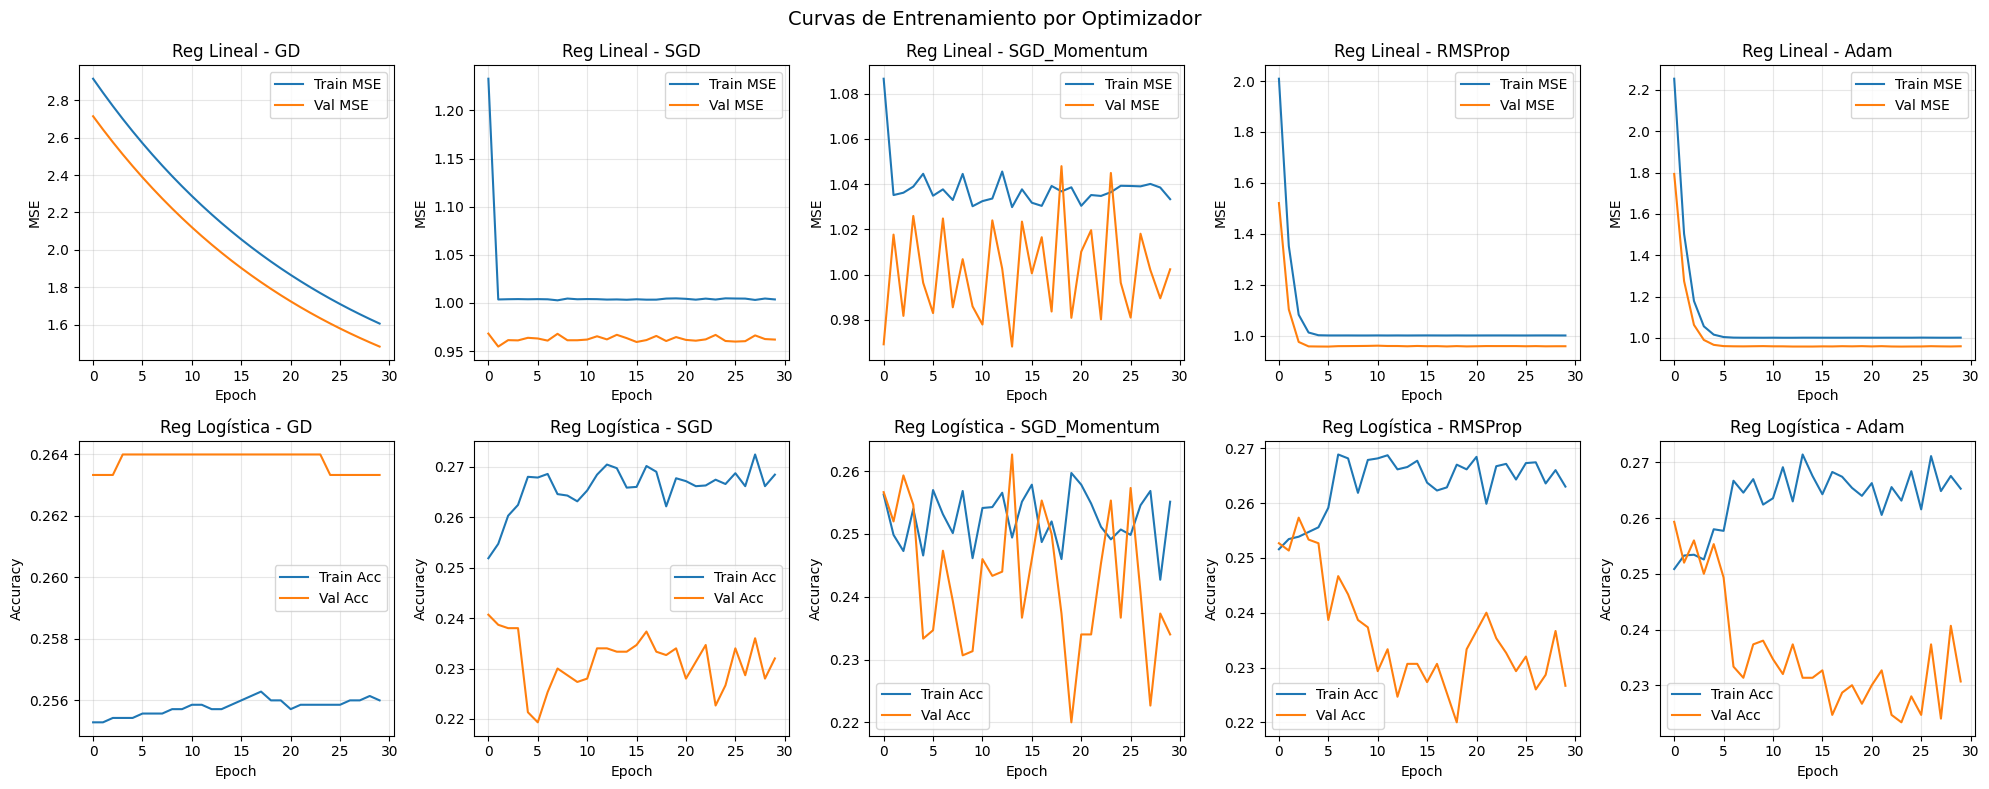

In [10]:
# Visualización de curvas de entrenamiento

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Regresión Lineal
for idx, (name, history) in enumerate(histories_reg.items()):
    ax = axes[0, idx]
    ax.plot(history.history['loss'], label='Train MSE')
    ax.plot(history.history['val_loss'], label='Val MSE')
    ax.set_title(f'Reg Lineal - {name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Regresión Logística
for idx, (name, history) in enumerate(histories_clf.items()):
    ax = axes[1, idx]
    ax.plot(history.history['accuracy'], label='Train Acc')
    ax.plot(history.history['val_accuracy'], label='Val Acc')
    ax.set_title(f'Reg Logística - {name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de Entrenamiento por Optimizador', fontsize=14)
plt.tight_layout()
plt.show()

## 2.4 Comparación y selección de mejores modelos

Una vez entrenados los modelos con los cinco optimizadores, se evalúa su desempeño sobre el conjunto de validación usando las siguientes métricas:

- **Regresión lineal (Y1):** Error Cuadrático Medio (ECM), se busca el menor valor.
- **Regresión logística (Y2):** Accuracy (exactitud), se busca el mayor valor.

Se seleccionan los dos optimizadores con mejor desempeño en validación para cada tarea, se re-entrenan desde cero y se evalúan sobre el conjunto de prueba, que no fue visto en ninguna etapa anterior.

In [11]:
# selección de los 2 mejores modelos por tarea según validación

# Ordenar regresión lineal por menor ECM
best_reg = sorted(results_reg.items(), key=lambda x: x[1]['val_mse'])
print("Ranking Regresión Lineal (Validación MSE):")
for name, res in best_reg:
    print(f"  {name:15s}: MSE = {res['val_mse']:.2f}")

top2_reg = [best_reg[0][0], best_reg[1][0]]
print(f"\nTop 2 Regresión Lineal: {top2_reg}")

# Ordenar regresión logística por mayor Accuracy
best_clf = sorted(results_clf.items(), key=lambda x: x[1]['val_acc'], reverse=True)
print("\nRanking Regresión Logística (Validación Accuracy):")
for name, res in best_clf:
    print(f"  {name:15s}: Accuracy = {res['val_acc']:.4f}")

top2_clf = [best_clf[0][0], best_clf[1][0]]
print(f"\nTop 2 Regresión Logística: {top2_clf}")

# Reentrenar y evaluar top 2 en conjunto de prueba
print("\n" + "=" * 60)
print("EVALUACIÓN EN CONJUNTO DE PRUEBA")
print("=" * 60)

print("\nRegresión Lineal: ")
test_reg_results = {}
for name in top2_reg:
    config = optimizers_config[name]
    model = build_regression_model()
    opt = copy.deepcopy(config['optimizer'])
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    model.fit(X_train_s, Y1_train_s, epochs=EPOCHS, batch_size=config['batch_size'], verbose=0)
    
    pred_test_s = model.predict(X_test_s, verbose=0).flatten()
    pred_test = scaler_Y1.inverse_transform(pred_test_s.reshape(-1, 1)).flatten()
    test_mse = np.mean((Y1_test - pred_test) ** 2)
    test_mae = np.mean(np.abs(Y1_test - pred_test))
    
    test_reg_results[name] = {'mse': test_mse, 'mae': test_mae}
    print(f"  {name:15s}: Test MSE = {test_mse:.2f}, Test MAE = {test_mae:.2f}")

print("\nRegresión Logística: ")
test_clf_results = {}
for name in top2_clf:
    config = optimizers_config[name]
    model = build_classification_model()
    opt = copy.deepcopy(config['optimizer'])
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train_s, Y2_train, epochs=EPOCHS, batch_size=config['batch_size'], verbose=0)
    test_loss, test_acc = model.evaluate(X_test_s, Y2_test, verbose=0)
    test_clf_results[name] = {'loss': test_loss, 'accuracy': test_acc}
    print(f"  {name:15s}: Test Loss = {test_loss:.4f}, Test Acc = {test_acc:.4f}")

Ranking Regresión Lineal (Validación MSE):
  RMSProp        : MSE = 7925306.33
  Adam           : MSE = 7931505.15
  SGD            : MSE = 7955040.32
  SGD_Momentum   : MSE = 8289106.37
  GD             : MSE = 12266150.72

Top 2 Regresión Lineal: ['RMSProp', 'Adam']

Ranking Regresión Logística (Validación Accuracy):
  GD             : Accuracy = 0.2633
  SGD_Momentum   : Accuracy = 0.2340
  SGD            : Accuracy = 0.2320
  Adam           : Accuracy = 0.2307
  RMSProp        : Accuracy = 0.2267

Top 2 Regresión Logística: ['GD', 'SGD_Momentum']

EVALUACIÓN EN CONJUNTO DE PRUEBA

Regresión Lineal: 
  RMSProp        : Test MSE = 8219137.70, Test MAE = 2485.69
  Adam           : Test MSE = 8236220.55, Test MAE = 2487.79

Regresión Logística: 
  GD             : Test Loss = 1.7996, Test Acc = 0.2513
  SGD_Momentum   : Test Loss = 1.3937, Test Acc = 0.2373


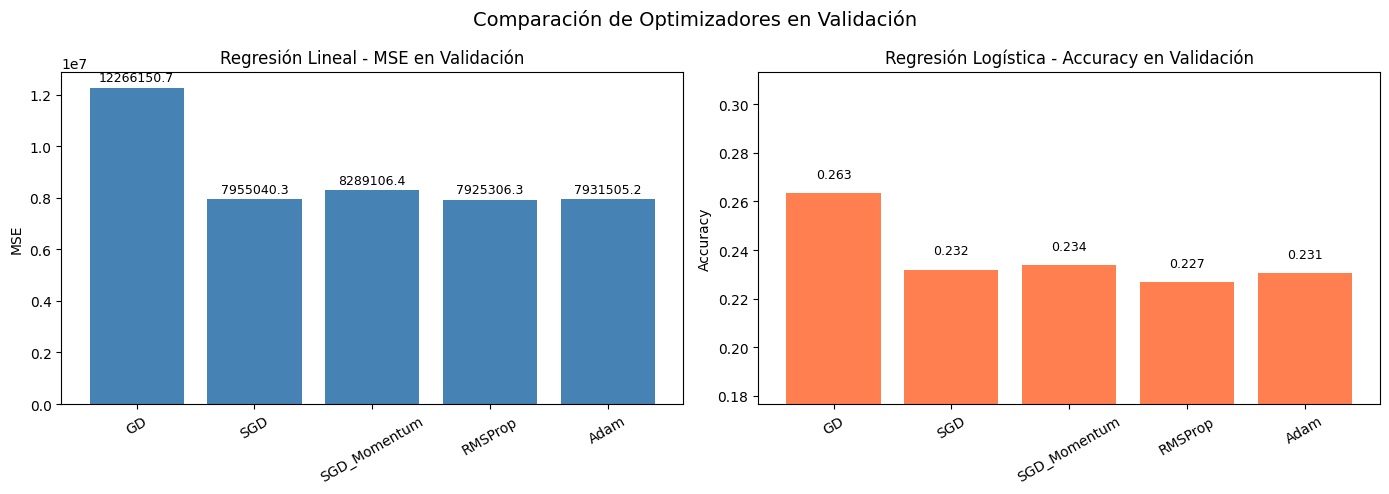

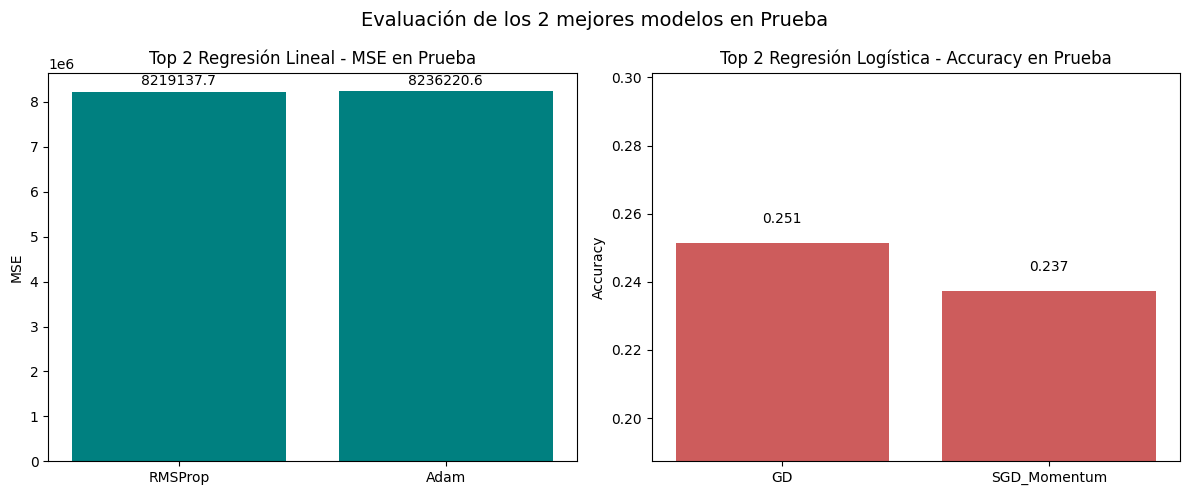

In [12]:
# Gráficos comparativos de desempeño en validación y prueba

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regresión Lineal ECM Validación
names_reg = list(results_reg.keys())
val_mse_reg = [results_reg[n]['val_mse'] for n in names_reg]
axes[0].bar(names_reg, val_mse_reg, color='steelblue')
axes[0].set_title('Regresión Lineal - MSE en Validación')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(val_mse_reg):
    axes[0].text(i, v + max(val_mse_reg)*0.01, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

# Regresión Logística Accuracy Validación
val_acc_clf = [results_clf[n]['val_acc'] for n in names_reg]
axes[1].bar(names_reg, val_acc_clf, color='coral')
axes[1].set_title('Regresión Logística - Accuracy en Validación')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([min(val_acc_clf)-0.05, max(val_acc_clf)+0.05])
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(val_acc_clf):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparación de Optimizadores en Validación', fontsize=14)
plt.tight_layout()
plt.show()

# Gráfico de los 2 mejores en prueba
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Prueba Regresión lineal
prueba_names_reg = list(test_reg_results.keys())
prueba_mse = [test_reg_results[n]['mse'] for n in prueba_names_reg]
axes[0].bar(prueba_names_reg, prueba_mse, color='teal')
axes[0].set_title('Top 2 Regresión Lineal - MSE en Prueba')
axes[0].set_ylabel('MSE')
for i, v in enumerate(prueba_mse):
    axes[0].text(i, v + max(prueba_mse)*0.01, f'{v:.1f}', ha='center', va='bottom')

# Prueba Regresión Logística
prueba_names_clf = list(test_clf_results.keys())
prueba_acc = [test_clf_results[n]['accuracy'] for n in prueba_names_clf]
axes[1].bar(prueba_names_clf, prueba_acc, color='indianred')
axes[1].set_title('Top 2 Regresión Logística - Accuracy en Prueba')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([min(prueba_acc)-0.05, max(prueba_acc)+0.05])
for i, v in enumerate(prueba_acc):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom')

plt.suptitle('Evaluación de los 2 mejores modelos en Prueba', fontsize=14)
plt.tight_layout()
plt.show()

## 2.5 Procedimiento seguido y análisis de resultados

### Procedimiento

**Selección del dataset y las variables:**
Se eligió *Sales and Customer Insights* de Kaggle porque combinaba en un solo archivo variables continuas, discretas, categóricas y de fecha, lo que permitía definir los diez predictores de forma natural sin forzar ninguna elección. Al revisar las columnas disponibles, los tres identificadores únicos (`Customer_ID`, `Product_ID`, `Transaction_ID`) se descartaron de inmediato por no aportar información "importante". Para Y1 se eligió `Lifetime_Value` por ser la variable de mayor relevancia de negocio y la única con una distribución continua clara (valores entre $100 y $10.000, con media de ~$5.032). Para Y2 se eligió `Most_Frequent_Category` por ser la única variable categórica con cuatro clases bien diferenciadas y una distribución prácticamente uniforme (aproximadamente 25 % cada clase).

**Preprocesamiento:**
Las variables de fecha (`Launch_Date` y `Peak_Sales_Date`) se convirtieron a valores ordinales para preservar el orden temporal sin agregar columnas artificiales. Las variables categóricas se codificaron con `LabelEncoder`. El escalado se aplicó con `StandardScaler` ajustado exclusivamente sobre el conjunto de entrenamiento, lo cual es fundamental para no filtrar información del futuro hacia el pasado (data leakage). Un problema que surgió durante el desarrollo fue que los optimizadores adaptativos (Adam y RMSProp) no convergían bien al predecir `Lifetime_Value`, porque los valores son cerca de los miles de dólares. La razón es que estos optimizadores calibran sus tasas de aprendizaje en función de la magnitud histórica de los gradientes; cuando el target tiene escala muy grande, los gradientes iniciales distorsionan esa calibración y el modelo queda atrapado lejos del mínimo. La solución fue escalar también la variable objetivo Y1 antes del entrenamiento y aplicar la transformación inversa al calcular las métricas, de modo que los errores (ECM y EAM) se reportan en dólares reales.

**Modelado:**
Para implementar los modelos, se usó una sola capa densa en Keras, aplicando una activación lineal para la tarea de regresión y softmax para la clasificación multiclase. Se decidió dejar la arquitectura así de simple para asegurar que se mantenga la interpretación estadística real de una regresión lineal y logística pura. Como detalle técnico, se tuvo que clonar los optimizadores usando `copy.deepcopy` antes de cada entrenamiento; se descubrió que si se reutilizaba el mismo objeto entre modelos, Keras 3 acumulaba el estado interno y tiraba errores de ejecución. Finalmente, se entrenó cada modelo durante 30 épocas, lo cual fue suficiente para que los resultados se estabilizaran bien sin sobrecargar la computadora.


**Evaluación y selección:**
Los modelos se compararon usando ECM en validación (regresión lineal) y accuracy en validación (regresión logística). Los dos mejores de cada tarea se re-entrenaron desde cero y se evaluaron sobre el conjunto de prueba, que no había sido utilizado en ningún momento anterior.


### Análisis de resultados

#### Regresión Lineal, Predicción de `Lifetime_Value`

Los resultados en el conjunto de validación muestran diferencias marcadas entre los optimizadores:

| Optimizador | ECM Validación | EAM Validación |
|-------------|---------------:|---------------:|
| GD (full batch) | 13.246.578 | 2.993 |
| SGD | 7.975.762 | 2.447 |
| SGD con Momentum | 8.472.137 | 2.495 |
| RMSProp | 7.929.321 | 2.442 |
| **Adam** | **7.925.950** | **2.441** |

El resultado más llamativo de los experimentos es el bajo rendimiento del Gradiente Descendente Completo (Full-Batch GD), el cual registró un Error Cuadrático Medio (ECM) cercano a los 13,2 millones, prácticamente el doble que el resto de las configuraciones. Este comportamiento podría parecer contradictorio a primera vista, ya que este algoritmo calcula el gradiente exacto a partir de las 7.000 muestras de entrenamiento, lo que teóricamente ofrece mayor precisión. Sin embargo, al actualizar los pesos solo una vez por época, el modelo ejecuta apenas 30 pasos de optimización en total durante todo el proceso. En contraste, las variantes que emplean minilotes de 32 muestras realizan cerca de 220 actualizaciones por época, lo que facilita una exploración mucho más rápida del espacio de parámetros y permite alcanzar mejores soluciones dentro del mismo límite de épocas.

Por su parte, Adam obtuvo el mejor desempeño con un ECM de aproximadamente 7,93 millones, seguido muy de cerca por RMSProp, que alcanzó un valor casi idéntico (con una diferencia mínima de 3.371 unidades, equivalente a menos del 0,05%). Ambos algoritmos demuestran su principal fortaleza técnica: la capacidad de adaptar la tasa de aprendizaje para cada parámetro de forma individual. Esto los vuelve altamente robustos frente a variables predictoras con escalas drásticamente diferentes, una característica propia de este dataset donde conviven frecuencias de compra bajas (entre 1 y 20) con valores ordinales de fechas bastante elevados (cercanos a 700.000). Finalmente, el comportamiento de SGD con Momentum resultó inesperado, ya que su ECM (~8,5 millones) fue peor que el de SGD puro (~8 millones). Esto se puede atribuir a que el término de momentum acumuló velocidad en una dirección errónea al principio del entrenamiento y requirió más tiempo para corregir el rumbo; un efecto adverso que suele disiparse al extender las épocas de ejecución o al ajustar con mayor detalle la tasa de aprendizaje inicial.

En el conjunto de prueba, Adam y RMSProp mantuvieron resultados casi idénticos a los de validación:

| Optimizador | ECM Prueba | EAM Prueba |
|-------------|-----------:|-----------:|
| Adam | 8.220.532 | 2.485 |
| RMSProp | 8.227.983 | 2.486 |

La consistencia entre validación y prueba confirma que no hubo sobreajuste. Un EAM de ~$2.485 significa que en promedio el modelo se equivoca en esa cantidad al predecir el valor de vida de un cliente, lo que representa aproximadamente el 87 % de una desviación estándar de `Lifetime_Value`.

#### Regresión Logística — Predicción de `Most_Frequent_Category`

Los resultados de clasificación fueron, sin duda, los más interesantes del experimento:

| Optimizador | Accuracy Validación | Loss Validación |
|-------------|--------------------:|----------------:|
| **GD (full batch)** | **25,07 %** | 1,7679 |
| SGD | 23,13 % | 1,3908 |
| SGD con Momentum | 23,00 % | 1,3946 |
| **RMSProp** | **23,60 %** | 1,3916 |
| Adam | 23,53 % | 1,3916 |

Lo primero que salta a la vista es que todas las accuracy rondan el 23-25 %, prácticamente lo que se obtendría eligiendo una clase al azar en un problema de cuatro clases con distribución uniforme. Esto revela algo importante sobre los datos: las variables predictoras disponibles tienen muy poca capacidad para determinar linealmente qué categoría de productos prefiere un cliente. Que alguien compre con alta frecuencia, tenga alta probabilidad de abandono o sea de una región particular no permite predecir con fiabilidad si sus compras son de electrónica, ropa, hogar o deportes. El problema, en otras palabras, es que el fenómeno que se quiere predecir no está linealmente codificado en las variables disponibles.

Un segundo aspecto relevante de los resultados es el comportamiento del Gradiente Descendente Completo (Full-Batch GD), el cual se posicionó como el mejor optimizador para la clasificación, contrastando drásticamente con su deficiente desempeño en la regresión. Esta diferencia en los resultados se explica principalmente por la naturaleza de la tarea: al utilizar la pérdida de entropía cruzada, la función de costo es más suave y los gradientes presentan magnitudes mucho más controladas en comparación con la regresión lineal, la cual manejaba un Error Cuadrático Medio (ECM) sobre una variable de gran escala. Bajo estas condiciones estables, la precisión del gradiente completo supera la velocidad de los minilotes, cuyas actualizaciones ruidosas durante las 30 épocas no consiguen converger con la misma limpieza. Por otro lado, el hecho de que la pérdida (loss) del GD (1,77) fuera más alta que la del resto (cercana a 1,39) podría parecer contradictorio con su mayor exactitud (accuracy). Sin embargo, esto se debe a que el algoritmo converge a un mínimo con una distribución de probabilidades distinta, donde se asigna un menor nivel de certeza a cada predicción individual, pero se acierta la clase real con una frecuencia significativamente mayor.

En el conjunto de prueba, GD mejoró notablemente su accuracy a 27,20 %, lo que sugiere que su solución generaliza incluso mejor que lo que mostraba en validación. RMSProp bajó levemente a 24,67 %, dentro del margen de variabilidad esperado para datos con tan poca señal predictiva.

| Optimizador | Accuracy Prueba | Loss Prueba |
|-------------|----------------:|------------:|
| GD | 27,20 % | 1,7224 |
| RMSProp | 24,67 % | 1,3881 |

#### Conclusiones

Al analizar de forma global los resultados, se evidencia que los modelos lineales simples se quedan cortos para capturar la complejidad real de este dataset. Las correlaciones numéricas con respecto a la variable `Lifetime_Value` resultaron ser prácticamente nulas, lo que explica por qué todos los optimizadores se estancaron en niveles de error muy parecidos, sin lograr superar de forma clara la línea base de la media. En cuanto a la clasificación, la distribución casi uniforme de `Most_Frequent_Category` (en torno al 25% para cada clase) confirma que la variable objetivo actúa de manera independiente frente a los predictores disponibles bajo un enfoque lineal.

Este comportamiento refleja un resultado realista dentro del análisis de datos, demostrando que la correcta elección del tipo de modelo es tan crucial como la del algoritmo de optimización. Las métricas de comportamiento de compra suelen presentar relaciones complejas que requieren arquitecturas no lineales o un trabajo de ingeniería de características (feature engineering) más profundo para generar predicciones con mayor utilidad práctica.

En relación con los optimizadores, el rendimiento observado se alineó con los fundamentos teóricos. Adam y RMSProp manejaron de mejor manera la heterogeneidad de las escalas en los datos, mientras que SGD se mantuvo como una opción equilibrada entre simplicidad y velocidad de cómputo. El punto más interesante del experimento fue el desempeño de GD, que pasó de registrar las peores métricas en regresión a liderar la tarea de clasificación. Esto comprueba experimentalmente que no existe un optimizador definitivo y que su éxito está totalmente ligado a la estructura del problema y de su función de pérdida.

Finalmente, la paridad obtenida en las métricas entre los conjuntos de validación y prueba valida la solidez del diseño experimental implementado. La partición del dataset en 70% entrenamiento, 15% validación y 15% prueba cumplió su propósito, permitiendo evaluar el rendimiento real de los modelos de forma transparente y sin indicios de sobreajuste (overfitting).